# Silent Mistakes That Can Hurt Your Numerai Models

We train five LightGBMs and one Ridge model on Numerai v5.3 quantum features and Ender60, using every fourth training era. Validation is frozen through era 1224, after a 16-era embargo. 

The question for every section: *Can a model produce plausible predictions while the pipeline does something other than what we intended?*

In [1]:
from pathlib import Path
import gc
import hashlib
import json
import time

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.linear_model import Ridge

DATA = Path('data-v5.3')
ARTIFACT_ROOT = Path('hidden-mistakes-artifacts')
TARGET = 'target_ender_60'
BENCHMARK = 'v53_lgbm_ender60'
SEEDS = [1, 7, 23, 42, 89]
FIRST_ERA, LAST_ERA = 591, 1224
N_TREES = 400
FORCE_RETRAIN = False  # Set True to train again; False loads this notebook's cache.
LGBM_PARAMS = {
    'objective': 'regression', 'metric': 'None', 'learning_rate': 0.03,
    'num_leaves': 31, 'max_depth': 5, 'min_data_in_leaf': 1000,
    'feature_fraction': 0.60, 'bagging_fraction': 0.80, 'bagging_freq': 1,
    'lambda_l2': 1.0, 'deterministic': True, 'force_col_wise': True,
    'verbosity': -1, 'num_threads': -1,
}
RIDGE_PARAMS = {
    'alpha': 100.0, 'solver': 'lsqr', 'tol': 1e-3, 'max_iter': 30,
    'fit_intercept': True, 'copy_X': False,
}
plt.style.use('seaborn-v0_8-whitegrid')
print('LightGBM', lgb.__version__, '| five seeds and Ridge | own cache:', ARTIFACT_ROOT)

LightGBM 4.6.0 | five seeds and Ridge | own cache: hidden-mistakes-artifacts


## Load the experiment once

The same ordered quantum features are used for all models. On a fresh run, this notebook loads every fourth training era, trains five LightGBMs and Ridge, predicts on validation, and saves its own artifacts. On later runs, it loads the cached predictions and only reads feature values for the small feature-order demonstration. The fixed era cutoff keeps the experiment reproducible.

In [2]:
feature_info = json.loads((DATA / 'features.json').read_text())
features = list(feature_info['feature_sets']['quantum'])
feature_hash = hashlib.sha256('\n'.join(features).encode()).hexdigest()
train_coverage = pd.read_parquet(DATA / 'train.parquet', columns=['era', TARGET])
train_coverage['era'] = train_coverage.era.astype(int)
coverage = train_coverage.groupby('era')[TARGET].agg(['size', 'count'])
complete_eras = coverage.index[coverage['size'] == coverage['count']].tolist()
train_eras = complete_eras[::4]
assert max(complete_eras) + 16 + 1 == FIRST_ERA
del train_coverage, coverage

valid = pd.read_parquet(
    DATA / 'validation.parquet', columns=['era', 'data_type', TARGET],
    filters=[('data_type', '==', 'validation'), ('era', '>=', f'{FIRST_ERA:04d}'), ('era', '<=', f'{LAST_ERA:04d}')],
)
valid['era'] = valid.era.astype(int)
valid = valid.drop(columns='data_type').dropna(subset=[TARGET])
benchmark = pd.read_parquet(
    DATA / 'validation_benchmark_models.parquet', columns=['era', BENCHMARK],
    filters=[('era', '>=', f'{FIRST_ERA:04d}'), ('era', '<=', f'{LAST_ERA:04d}')],
)
valid['benchmark'] = benchmark[BENCHMARK].reindex(valid.index)
valid = valid.dropna(subset=['benchmark'])
assert valid.era.min() == FIRST_ERA and valid.era.max() == LAST_ERA

signature = {
    'feature_hash': feature_hash, 'target': TARGET, 'benchmark': BENCHMARK,
    'train_eras': train_eras, 'validation_eras': [FIRST_ERA, LAST_ERA],
    'validation_index_hash': hashlib.sha256(
        pd.util.hash_pandas_object(valid.index, index=False).to_numpy(dtype=np.uint64).tobytes()
    ).hexdigest(),
    'trees': N_TREES, 'seeds': SEEDS, 'lgbm_params': LGBM_PARAMS, 'ridge_params': RIDGE_PARAMS,
}
run_id = hashlib.sha256(json.dumps(signature, sort_keys=True).encode()).hexdigest()[:12]
ARTIFACTS = ARTIFACT_ROOT / run_id
ARTIFACTS.mkdir(parents=True, exist_ok=True)
(ARTIFACTS / 'signature.json').write_text(json.dumps(signature, indent=2, sort_keys=True))
lgbm_files = [(ARTIFACTS / f'lightgbm_seed_{seed}.txt', ARTIFACTS / f'validation_seed_{seed}.npy') for seed in SEEDS]
ridge_files = (ARTIFACTS / 'ridge.joblib', ARTIFACTS / 'ridge_validation.npy')
need_fit = FORCE_RETRAIN or any(not model.exists() for model, _ in [*lgbm_files, ridge_files])
need_predict = need_fit or any(not pred.exists() for _, pred in [*lgbm_files, ridge_files])
print(f'{len(valid):,} labeled validation rows | {len(train_eras)} selected training eras | {len(features)} features')
print('Training required:', need_fit, '| prediction required:', need_predict, '| artifacts:', ARTIFACTS)

if need_fit:
    train = pd.read_parquet(
        DATA / 'train.parquet', columns=['era', *features, TARGET],
        filters=[('era', 'in', [f'{era:04d}' for era in train_eras])],
    ).dropna(subset=[TARGET])
    train['era'] = train.era.astype(int)
    X_train, y_train = train[features], train[TARGET]
if need_predict:
    validation_features = pd.read_parquet(
        DATA / 'validation.parquet', columns=['era', 'data_type', *features, TARGET],
        filters=[('data_type', '==', 'validation'), ('era', '>=', f'{FIRST_ERA:04d}'), ('era', '<=', f'{LAST_ERA:04d}')],
    ).loc[valid.index, features]
    assert list(validation_features.columns) == features
if need_fit:
    print(f'Training rows: {len(train):,}', flush=True)

models, predictions = {}, {}
for seed, (model_path, prediction_path) in zip(SEEDS, lgbm_files):
    trained_model = FORCE_RETRAIN or not model_path.exists()
    if not FORCE_RETRAIN and model_path.exists():
        print(f'LOAD LightGBM seed={seed}', flush=True)
        model = lgb.Booster(model_file=str(model_path))
    else:
        started = time.perf_counter()
        print(f'TRAIN LightGBM seed={seed}', flush=True)
        params = LGBM_PARAMS | {key: seed for key in ('seed', 'feature_fraction_seed', 'bagging_seed', 'data_random_seed')}
        model = lgb.train(params, lgb.Dataset(X_train, label=y_train, feature_name=features), num_boost_round=N_TREES)
        model.save_model(str(model_path))
        print(f'DONE seed={seed} in {(time.perf_counter() - started) / 60:.1f} min', flush=True)
    if not trained_model and prediction_path.exists():
        prediction = np.load(prediction_path)
    else:
        prediction = model.predict(validation_features, validate_features=True).astype(np.float32)
        np.save(prediction_path, prediction)
    assert model.feature_name() == features and len(prediction) == len(valid)
    models[seed], predictions[seed] = model, prediction

trained_ridge = FORCE_RETRAIN or not ridge_files[0].exists()
if not FORCE_RETRAIN and ridge_files[0].exists():
    print('LOAD Ridge', flush=True)
    ridge = joblib.load(ridge_files[0])
else:
    started = time.perf_counter()
    print('TRAIN Ridge', flush=True)
    ridge = Ridge(**RIDGE_PARAMS).fit(X_train, y_train)
    joblib.dump(ridge, ridge_files[0])
    print(f'DONE Ridge in {(time.perf_counter() - started) / 60:.1f} min', flush=True)
if not trained_ridge and ridge_files[1].exists():
    ridge_prediction = np.load(ridge_files[1])
else:
    ridge_prediction = ridge.predict(validation_features).astype(np.float32)
    np.save(ridge_files[1], ridge_prediction)
assert len(ridge_prediction) == len(valid)
if need_fit:
    del train, X_train, y_train
if need_predict:
    del validation_features
gc.collect()
print('Ready: five LightGBMs and Ridge')

3,964,033 labeled validation rows | 144 selected training eras | 807 features
Training required: False | prediction required: False | artifacts: hidden-mistakes-artifacts/3e0cbf61aefc
LOAD LightGBM seed=1


LOAD LightGBM seed=7


LOAD LightGBM seed=23


LOAD LightGBM seed=42


LOAD LightGBM seed=89


LOAD Ridge


Ready: five LightGBMs and Ridge


### Two metrics for every demonstration

CORR60 and BMC60 are calculated independently for each era, then averaged across eras. The code below mirrors `conference-01`; BMC60 uses the public benchmark prediction.

In [3]:
def gaussian_rank(values):
    ranks = pd.Series(values).rank(method='average', pct=True).to_numpy(np.float64)
    return stats.norm.ppf(np.clip(ranks, 1e-6, 1 - 1e-6))

def corr60(prediction, target):
    x = gaussian_rank(prediction)
    x = np.sign(x) * np.abs(x) ** 1.5
    x -= x.mean()
    y = target.astype(np.float64) - target.mean()
    y = np.sign(y) * np.abs(y) ** 1.5
    y -= y.mean()
    return float((x @ y) / max(np.sqrt(x @ x) * np.sqrt(y @ y), 1e-12))

def bmc60(prediction, benchmark_prediction, target):
    x = gaussian_rank(prediction)
    base = gaussian_rank(benchmark_prediction)
    x -= base * ((base @ x) / (base @ base + 1e-12))
    y = target.astype(np.float64) * 4.0
    y -= y.mean()
    return float((y @ x) / len(y))

def score(meta, candidates):
    rows = []
    eras = meta.era.to_numpy()
    target = meta[TARGET].to_numpy(np.float64)
    benchmark_values = meta.benchmark.to_numpy(np.float64)
    for era in sorted(meta.era.unique()):
        mask = eras == era
        for name, values in candidates.items():
            rows.append({'candidate': name, 'era': era,
                         'corr60': corr60(values[mask], target[mask]),
                         'bmc60': bmc60(values[mask], benchmark_values[mask], target[mask])})
    per_era = pd.DataFrame(rows)
    return per_era.groupby('candidate')[['corr60', 'bmc60']].mean().sort_values('corr60', ascending=False), per_era

def rank_per_era(values, eras):
    return values.groupby(eras, sort=False).rank(method='average', pct=True)

print('Scoring helpers ready')

Scoring helpers ready


# Mistake 1: 'The DataFrame has column names, so order is safe'

Shuffle the 807 quantum columns while preserving names, values, and shape. Default LightGBM prediction still returns numbers. Then enable `validate_features=True` and watch the same bad input fail.

**Audience question:** Which result would you expect from a model that receives the right columns in the wrong positions?

In [4]:
demo_eras = sorted(valid.era.unique())[-20:]
demo_meta = valid.loc[valid.era.isin(demo_eras)]
demo = pd.read_parquet(
    DATA / 'validation.parquet', columns=['era', 'data_type', *features, TARGET],
    filters=[('data_type', '==', 'validation'), ('era', '>=', f'{demo_eras[0]:04d}'), ('era', '<=', f'{demo_eras[-1]:04d}')],
).loc[demo_meta.index]
assert np.array_equal(demo.era.astype(int), demo_meta.era)
X = demo[features]
shuffled = list(np.random.default_rng(2026).permutation(features))
model = models[SEEDS[0]]
correct = model.predict(X, validate_features=True)
wrong = model.predict(X[shuffled])  # Same columns, silently wrong positions.
display(score(demo_meta, {'correct order': correct, 'wrong order': wrong})[0])
print('Prediction correlation:', round(float(np.corrcoef(correct, wrong)[0, 1]), 4))
try:
    model.predict(X[shuffled], validate_features=True)
except lgb.basic.LightGBMError:
    print('SAFE FAILURE: validate_features=True rejected the shuffled columns.')
else:
    raise AssertionError('Expected LightGBM to reject the feature mismatch')

,corr60,bmc60
candidate,,
correct order,0.016845,0.003295
wrong order,-0.012482,-0.009693


Prediction correlation: -0.0036
SAFE FAILURE: validate_features=True rejected the shuffled columns.


[LightGBM] [Fatal] Expected 'feature_abaxial_aesthetical_nitration' at position 0 but found 'feature_squeaking_awakened_llanelly'


**Observed:** on the final 20 eras, correct-order CORR60 is about **0.01685**; wrong-order CORR60 is about **-0.01248**. Prediction correlation is approximately zero.

**Safeguard:** save the ordered feature list with the model; compare its hash and use `validate_features=True` with pandas DataFrames. This catches names/order, **not** a feature whose values were calculated with the wrong recipe.

# Mistake 2: 'The seed is just an implementation detail'

These five models see the same rows and features and grow the same number of trees. Random feature and row subsampling change their fitted trees. First compare all five individual seeds; then add their predeclared per-era rank ensemble to the same comparison.

,corr60,bmc60
candidate,,
five-seed rank ensemble,0.025933,0.002524
seed_42,0.024146,0.002618
seed_7,0.024141,0.002408
seed_89,0.023901,0.002435
seed_23,0.023878,0.002365
seed_1,0.023663,0.001959


,seed,first_tree_root,top_gain_feature
0,1,feature_alaskan_equivocal_althea,feature_vocalic_leftish_babbler
1,7,feature_unassimilated_electroencephalographic_...,feature_vocalic_leftish_babbler
2,23,feature_alaskan_equivocal_althea,feature_fanciful_stubbly_trochlea
3,42,feature_advisory_environmental_canister,feature_unrewarded_waspier_polyuria
4,89,feature_alaskan_equivocal_althea,feature_alaskan_equivocal_althea


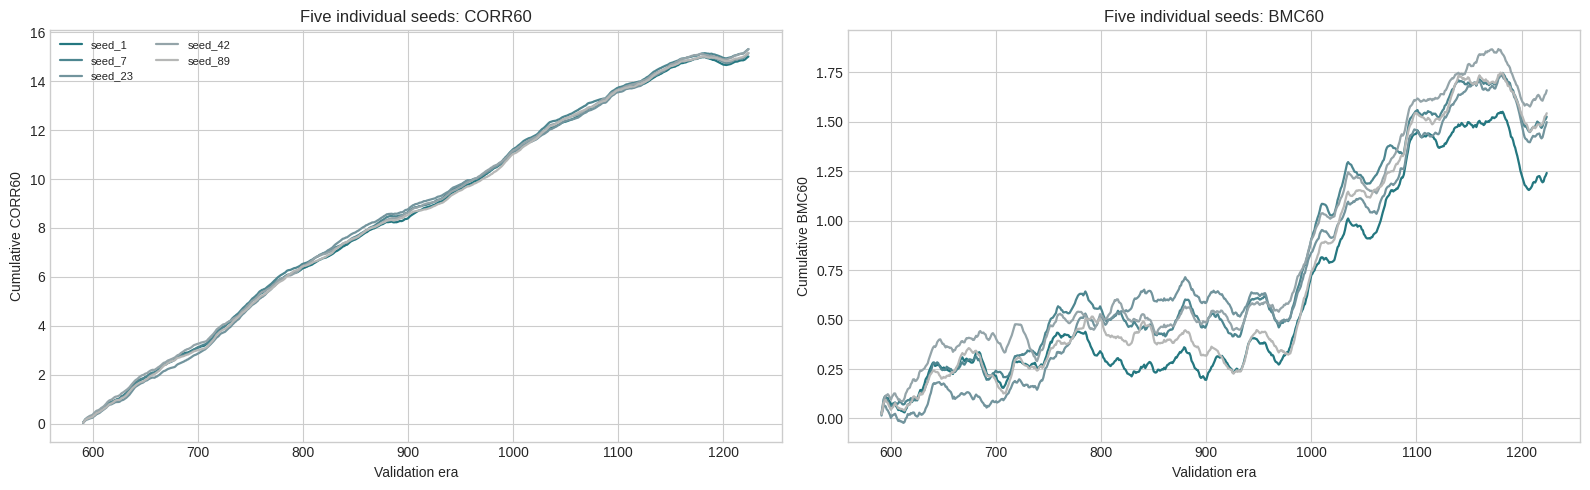

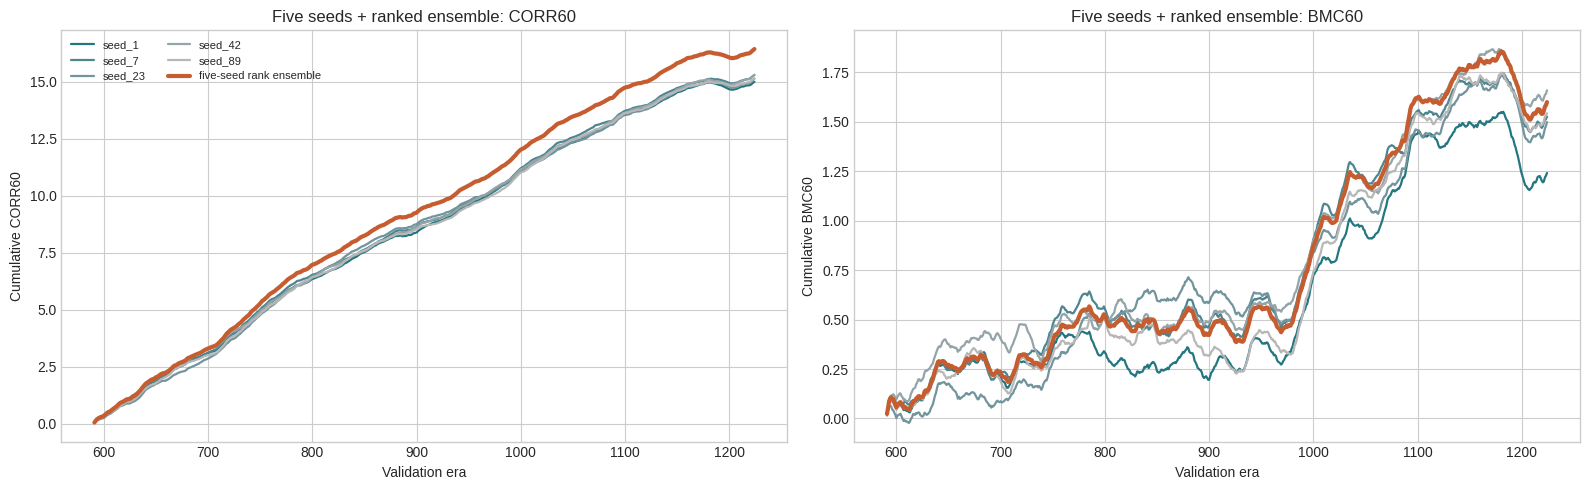

In [5]:
seed_frame = pd.DataFrame({f'seed_{s}': predictions[s] for s in SEEDS}, index=valid.index)
ranked_seed_frame = rank_per_era(seed_frame, valid.era)
seed_ensemble5 = rank_per_era(ranked_seed_frame.mean(axis=1), valid.era)
seed_candidates = {f'seed_{s}': predictions[s] for s in SEEDS}
seed_candidates['five-seed rank ensemble'] = seed_ensemble5.to_numpy()
seed_summary, seed_eras = score(valid, seed_candidates)
display(seed_summary)
roots = []
for seed in SEEDS:
    model = models[seed]
    first_tree = model.dump_model()['tree_info'][0]['tree_structure']
    roots.append({'seed': seed, 'first_tree_root': model.feature_name()[first_tree['split_feature']],
                  'top_gain_feature': model.feature_name()[int(np.argmax(model.feature_importance('gain')))]})
display(pd.DataFrame(roots))
seed_colors = dict(zip((f'seed_{seed}' for seed in SEEDS), ['#247780', '#4d8690', '#72949d', '#94a4a9', '#b6b7b6']))
for include_ensemble in (False, True):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    names = [f'seed_{seed}' for seed in SEEDS]
    if include_ensemble:
        names.append('five-seed rank ensemble')
    for name in names:
        frame = seed_eras.loc[seed_eras.candidate == name].sort_values('era')
        is_ensemble = name == 'five-seed rank ensemble'
        style = {'label': name, 'color': '#c65d31' if is_ensemble else seed_colors[name], 'linewidth': 3 if is_ensemble else 1.6}
        axes[0].plot(frame.era, frame.corr60.cumsum(), **style)
        axes[1].plot(frame.era, frame.bmc60.cumsum(), **style)
    title = 'Five seeds + ranked ensemble' if include_ensemble else 'Five individual seeds'
    axes[0].set(title=f'{title}: CORR60', xlabel='Validation era', ylabel='Cumulative CORR60')
    axes[1].set(title=f'{title}: BMC60', xlabel='Validation era', ylabel='Cumulative BMC60')
    axes[0].legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### A related trap: picking the winner on the final report

The highest full-validation seed is **not** an unbiased estimate of how that selected seed will do later. Choose among the five individual seeds on earlier eras and report a later block, leaving a 16-era gap. The predeclared five-seed ensemble is a reference, not selected after seeing later results.

,earlier_selection,later_report
candidate,,
five-seed rank ensemble,0.030210,0.021918
seed_23,0.028597,0.019450
seed_7,0.028252,0.020367
seed_42,0.027997,0.020461
seed_89,0.027766,0.020406
seed_1,0.027456,0.020128


Selected seed using earlier eras: seed_23
Its later CORR60: 0.01945


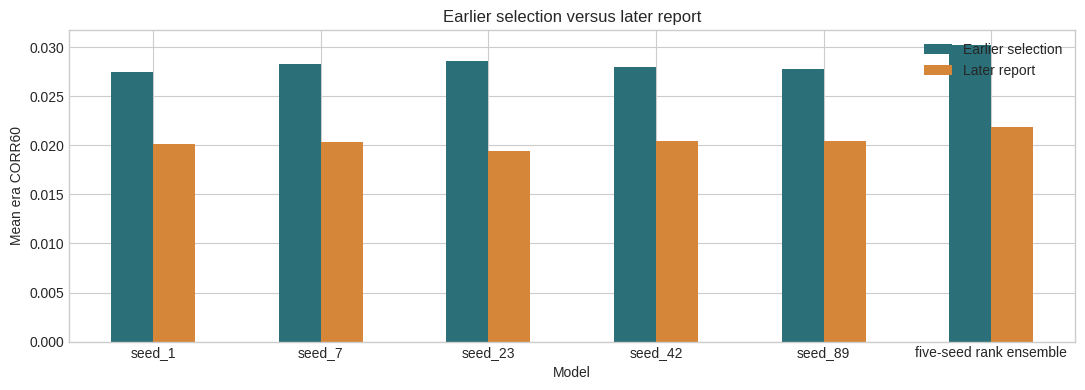

In [6]:
eras = sorted(seed_eras.era.unique())
middle = len(eras) // 2
early_eras, later_eras = eras[:middle - 16], eras[middle:]
assert later_eras[0] - early_eras[-1] > 16
early = seed_eras[seed_eras.era.isin(early_eras)].groupby('candidate').corr60.mean()
later = seed_eras[seed_eras.era.isin(later_eras)].groupby('candidate').corr60.mean()
period_comparison = pd.DataFrame({'earlier_selection': early, 'later_report': later})
display(period_comparison.sort_values('earlier_selection', ascending=False))
chosen_seed = early[[f'seed_{s}' for s in SEEDS]].idxmax()
print('Selected seed using earlier eras:', chosen_seed)
print('Its later CORR60:', round(float(later[chosen_seed]), 6))
ax = period_comparison.loc[[*(f'seed_{s}' for s in SEEDS), 'five-seed rank ensemble']].plot.bar(
    figsize=(11, 4), rot=0, color=['#2b6f78', '#d58638']
)
ax.set(title='Earlier selection versus later report', xlabel='Model', ylabel='Mean era CORR60')
ax.legend(['Earlier selection', 'Later report'])
plt.tight_layout()
plt.show()

**Safeguard:** record seeds as part of the model configuration. Predefine a seed ensemble, or select seeds on an earlier inner-validation block and leave later eras untouched for reporting.

# Mistake 3: 'A raw 50/50 average gives two models equal influence'

Use **LightGBM seed 42 and Ridge** trained above on the same rows and quantum features, as in `conference-02`. Different algorithms produce different rankings and raw output scales. Compare raw averaging with ranking **each model within each era**, averaging the ranks, and reranking.

Then change Ridge's raw prediction scale without changing its ranking or individual scores. The scale sweep is a deliberate stress test, not a way to tune an ensemble on final validation.

Prediction Spearman correlation: 0.562


,mean,std,min,max
LightGBM,0.500632,0.010157,0.442420,0.557609
Ridge,0.499947,0.012897,0.429552,0.570647


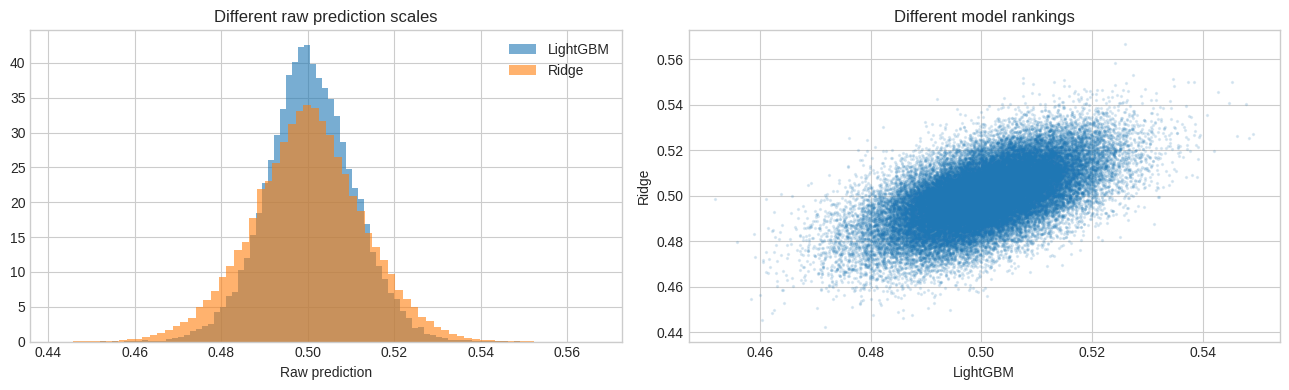

,corr60,bmc60
candidate,,
LightGBM,0.024146,0.002618
"rank each era, 50/50 average",0.022724,0.001934
raw 50/50 average,0.022382,0.001838
Ridge,0.016636,0.000858


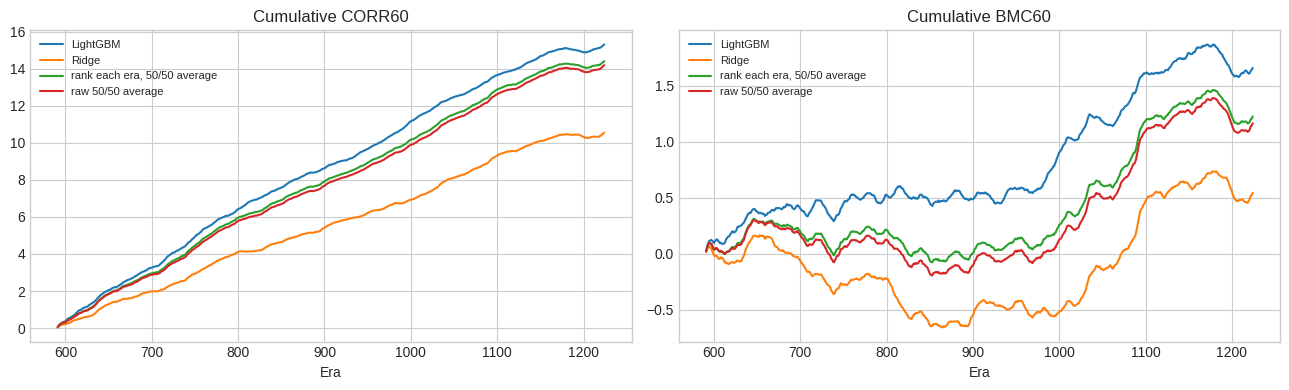

,corr60,bmc60,ridge_multiplier
candidate,,,
raw x0.05,0.024273,0.002573,0.05
raw x0.1,0.024353,0.002530,0.10
raw x0.25,0.024301,0.002388,0.25
raw x0.5,0.023705,0.002146,0.50
raw x1,0.022382,0.001838,1.00
raw x2,0.020556,0.001494,2.00
raw x4,0.018967,0.001225,4.00
raw x10,0.017682,0.001020,10.00
raw x20,0.017185,0.000945,20.00


Maximum rank-ensemble change when Ridge is multiplied by 10: 0.0


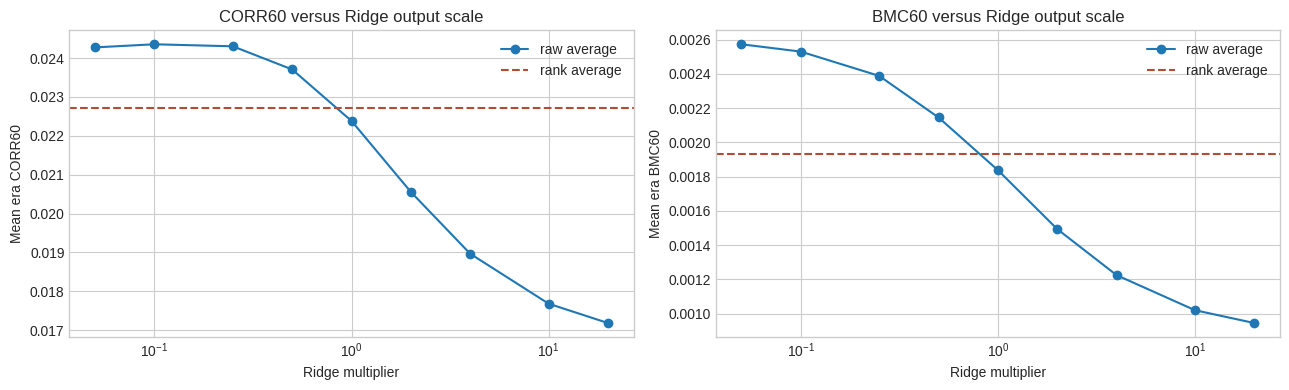

In [7]:
pair = pd.DataFrame({'LightGBM': predictions[42].astype(np.float64), 'Ridge': ridge_prediction.astype(np.float64)}, index=valid.index)
print('Prediction Spearman correlation:', round(float(pair.corr(method='spearman').iloc[0, 1]), 3))
display(pair.agg(['mean', 'std', 'min', 'max']).T)
sample = pair.sample(50_000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sample.LightGBM, bins=70, alpha=0.6, density=True, label='LightGBM')
axes[0].hist(sample.Ridge, bins=70, alpha=0.6, density=True, label='Ridge')
axes[0].set(title='Different raw prediction scales', xlabel='Raw prediction')
axes[0].legend()
axes[1].scatter(sample.LightGBM, sample.Ridge, s=2, alpha=0.12)
axes[1].set(title='Different model rankings', xlabel='LightGBM', ylabel='Ridge')
plt.tight_layout()
plt.show()

natural_raw = pair.mean(axis=1)
natural_rank = rank_per_era(rank_per_era(pair, valid.era).mean(axis=1), valid.era)
ensemble_summary, ensemble_eras = score(valid, {
    'LightGBM': pair.LightGBM.to_numpy(),
    'Ridge': pair.Ridge.to_numpy(),
    'raw 50/50 average': natural_raw.to_numpy(),
    'rank each era, 50/50 average': natural_rank.to_numpy(),
})
display(ensemble_summary)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, frame in ensemble_eras.groupby('candidate'):
    frame = frame.sort_values('era')
    axes[0].plot(frame.era, frame.corr60.cumsum(), label=name)
    axes[1].plot(frame.era, frame.bmc60.cumsum(), label=name)
axes[0].set(title='Cumulative CORR60', xlabel='Era')
axes[1].set(title='Cumulative BMC60', xlabel='Era')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

scales = [0.05, 0.10, 0.25, 0.50, 1, 2, 4, 10, 20]
scale_candidates = {f'raw x{scale:g}': (pair.LightGBM + scale * pair.Ridge).to_numpy() / 2 for scale in scales}
scale_summary, _ = score(valid, scale_candidates)
scale_summary['ridge_multiplier'] = scale_summary.index.str.extract(r'raw x(.+)', expand=False).astype(float)
scale_summary = scale_summary.sort_values('ridge_multiplier')
display(scale_summary)
scaled_pair = pair.copy()
scaled_pair['Ridge'] *= 10
scaled_rank = rank_per_era(rank_per_era(scaled_pair, valid.era).mean(axis=1), valid.era)
assert np.array_equal(natural_rank.to_numpy(), scaled_rank.to_numpy())
print('Maximum rank-ensemble change when Ridge is multiplied by 10:', np.max(np.abs(natural_rank.to_numpy() - scaled_rank.to_numpy())))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(('corr60', 'bmc60'), axes):
    ax.plot(scale_summary.ridge_multiplier, scale_summary[metric], marker='o', label='raw average')
    ax.axhline(ensemble_summary.loc['rank each era, 50/50 average', metric], color='#b24c35', linestyle='--', label='rank average')
    ax.set_xscale('log')
    ax.set(title=f'{metric.upper()} versus Ridge output scale', xlabel='Ridge multiplier', ylabel=f'Mean era {metric.upper()}')
    ax.legend()
plt.tight_layout()
plt.show()

**Observed:** with LightGBM and Ridge, the natural per-era rank average beats the natural raw 50/50 average on both CORR60 and BMC60 in this snapshot. The raw ensemble varies across arbitrary Ridge scale multipliers; the rank ensemble is unchanged. Some raw scale choices may still score better than ranking, so this is not a universal claim that rank averaging maximizes backtest scores.

**Safeguard:** if you intend equal model influence, rank each model *within each era* before averaging. A final rank after raw averaging does not undo the unequal influence already introduced by raw scales.

# The production checklist

| Silent assumption | Check before submission |
|:--|:--|
| Column names make prediction safe | Compare the **ordered** feature list and hash; pass `validate_features=True` |
| A seed cannot change the model much | Record seeds and inspect variation; avoid selecting on final reporting eras |
| `0.5 * A + 0.5 * B` means equal influence | Inspect prediction scales; rank each model per era if equal influence is intended |
| Cached predictions align because row counts match | Save row IDs or an ordered-index hash alongside cached predictions |

**A valid-looking submission is not proof that the pipeline produced the predictions you intended.**